# 05 — Market Opportunity

## Objective
Quantify the addressable UK demographic for teen sleepwear, assess market stability through population forecasting, and frame the overall opportunity with a clear-eyed view of both potential and risk.

This notebook draws on:
- **Notebook 01** — pricing landscape and positioning gap (20 brands, UK and US)
- **Notebook 02** — search seasonality and discovery channels
- **Notebook 03** — social media benchmarks and engagement patterns
- **Notebook 04** — competitive positioning synthesis and strategic models

### Data Source
Office for National Statistics (ONS) mid-year population estimates. National-level data for the United Kingdom, by single year of age and sex. Time period: mid-year (30 June) 2011–2024.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
DATA_DIR = Path('data')

print('Ready')

Ready


---
## Section 1: UK Population Data — Ages 5–19 (2011–2024)

In [2]:
df = pd.read_excel(
    DATA_DIR / 'uk_ons_population_age.xlsx',
    sheet_name=0,
    skiprows=4,
    header=0
)

df.columns = df.columns.str.strip()
df = df.rename(columns={'1_year': '1_years'})

# Filter to UK-level rows only (avoid double-counting)
df = df[df['Area_name'] == 'United Kingdom'].reset_index(drop=True)

# Ensure numeric age columns
age_cols_all = [f'{i}_years' for i in range(1, 20)]
for col in age_cols_all:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'Loaded {len(df)} UK-level rows ({df["Year_ending_30_June"].min()}–{df["Year_ending_30_June"].max()})')

Loaded 28 UK-level rows (2011–2024)


---
## Section 2: Population Trends by Age (8–19)

How has the target demographic changed over the past 13 years?

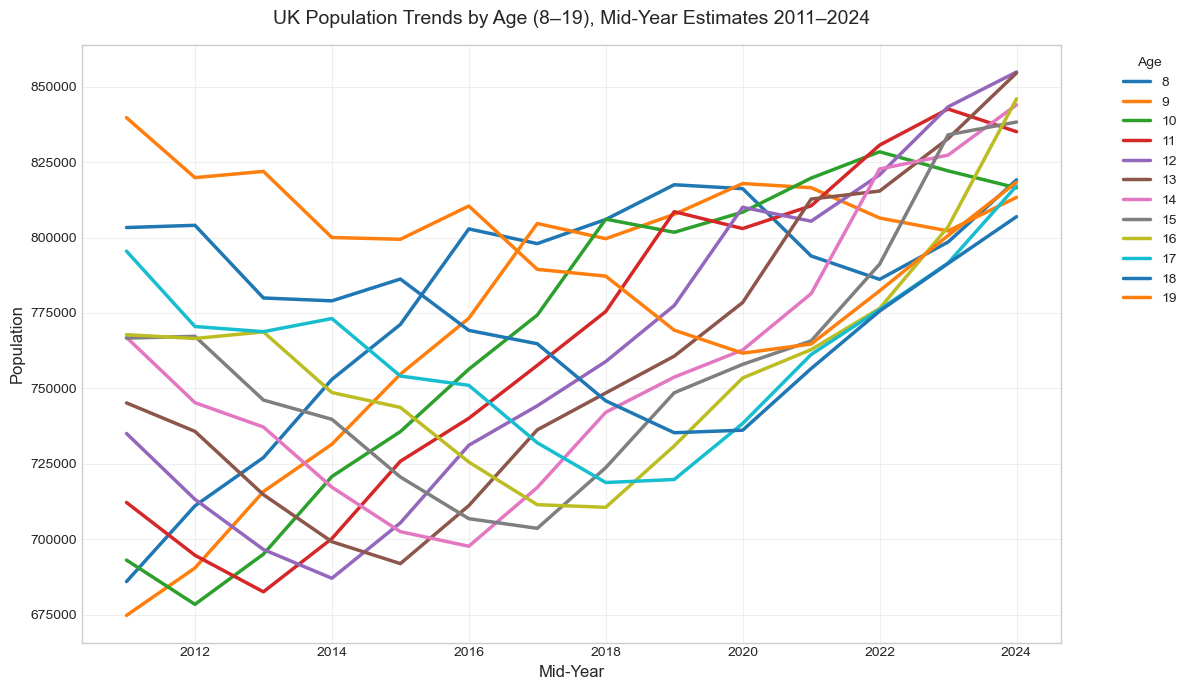

In [3]:
age_cols = [f'{i}_years' for i in range(8, 20)]

age_trends = df.groupby('Year_ending_30_June')[age_cols].sum().reset_index()
age_trends = age_trends.rename(columns={'Year_ending_30_June': 'mid_year'})
age_trends['mid_year'] = pd.to_numeric(age_trends['mid_year'])

long_trends = age_trends.melt(
    id_vars='mid_year',
    value_vars=age_cols,
    var_name='Age',
    value_name='Population'
)
long_trends['Age_num'] = long_trends['Age'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=long_trends,
    x='mid_year',
    y='Population',
    hue='Age_num',
    palette='tab10',
    linewidth=2.5
)
plt.title('UK Population Trends by Age (8–19), Mid-Year Estimates 2011–2024',
          fontsize=14, pad=15)
plt.xlabel('Mid-Year', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart Commentary — Age Trends

Individual age groups from 8 to 19 tracked over 2011–2024 (ONS mid-year estimates).

The mid-2010s dip (most visible ~2014–2018) reflects smaller early-2000s birth cohorts. Since ~2018, all age groups show a clear upward trend, with most reaching ~800K–860K by 2024. Younger groups (8–12) are catching up as larger mid-2000s/early-2010s cohorts enter.

The 8–19 segment has grown modestly in absolute terms — resilient despite lower recent births, supported by net migration and past cohort sizes. This provides a stable, non-shrinking demographic base for the target market.

---
## Section 3: Boys vs Girls — Sex Split

Relevant for product positioning: is the demographic skewed?

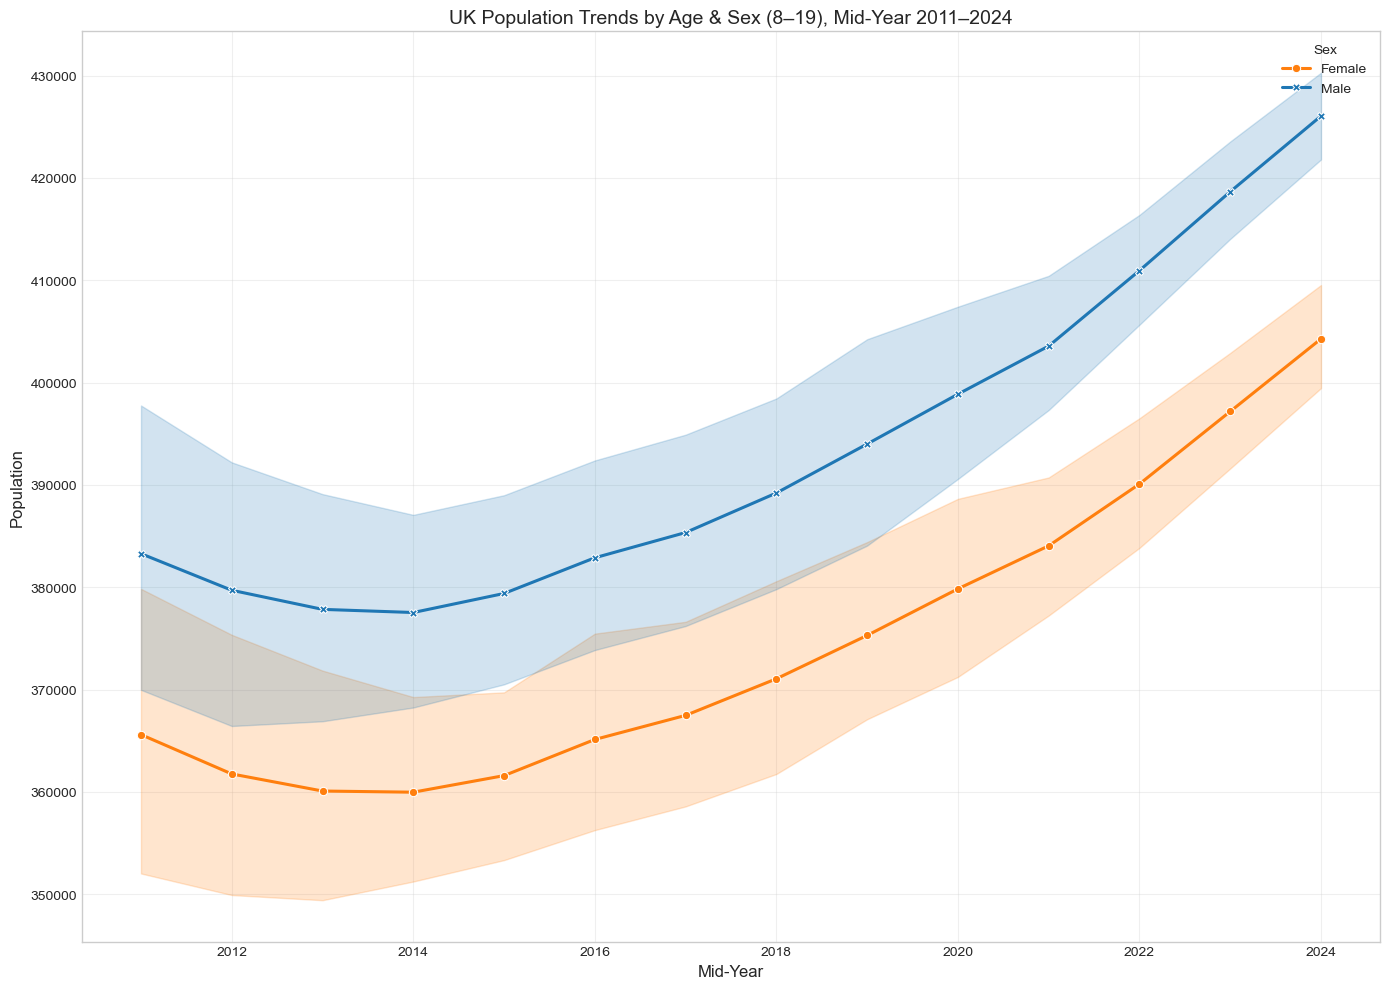

In [4]:
sex_age = df.groupby(['Year_ending_30_June', 'Sex'])[age_cols].sum().reset_index()
sex_age = sex_age.rename(columns={'Year_ending_30_June': 'mid_year'})
sex_age['mid_year'] = pd.to_numeric(sex_age['mid_year'])

long_sex = sex_age.melt(
    id_vars=['mid_year', 'Sex'],
    value_vars=age_cols,
    var_name='Age',
    value_name='Population'
)
long_sex['Age_num'] = long_sex['Age'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(14, 10))
sns.lineplot(
    data=long_sex,
    x='mid_year',
    y='Population',
    hue='Sex',
    style='Sex',
    markers=True,
    dashes=False,
    palette={'Male': '#1f77b4', 'Female': '#ff7f0e'},
    linewidth=2.2
)
plt.title('UK Population Trends by Age & Sex (8–19), Mid-Year 2011–2024',
          fontsize=14)
plt.xlabel('Mid-Year', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.legend(title='Sex', loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart Commentary — Sex Split

Boys consistently outnumber girls across ages 8–19, reflecting the natural sex ratio at birth (~105 boys per 100 girls). The gap is small but consistent.

For a brand initially targeting girls (following the PPP and Katie J NYC model), the female 11–19 population is approximately 49.5% of the total — roughly 3.7M. This is the core addressable demographic for gap sizing. A unisex or boys-inclusive expansion would access the full ~7.5M.

---
## Section 4: Population Forecast — Cohort-Component Model (2025–2035)

Rolling forward actual 2024 cohorts year-by-year to project the 5–19 and 11–19 populations under three scenarios.

In [5]:
base_year = df['Year_ending_30_June'].max()

# Build historical per-age populations (both sexes combined)
historical = {}
for _, row in df.iterrows():
    yr = row['Year_ending_30_June']
    for age in range(1, 23):
        col = f'{age}_years'
        if col in df.columns:
            historical[(yr, age)] = historical.get((yr, age), 0) + row[col]

print(f'Base year: {base_year}')
print(f'Per-age populations in {base_year} (ages 5–19):')
for age in range(5, 20):
    print(f'  Age {age:2d}: {historical[(base_year, age)]:>10,.0f}')


def make_forecast(survival_rate, incoming_growth):
    """
    Cohort-component forecast for ages 5–19, 2025–2035.
    
    Tracks actual cohorts as they age:
    - Each age group ages up one year
    - Survival rate accounts for net migration + near-zero child mortality
    - New 5-year-olds enter each year at incoming_growth rate
    """
    years = list(range(base_year + 1, 2036))
    pop = dict(historical)
    base_5yo = historical[(base_year, 5)]

    for y in years:
        ahead = y - base_year
        pop[(y, 5)] = base_5yo * (incoming_growth ** ahead)
        for age in range(6, 20):
            prev = pop.get((y - 1, age - 1), 0)
            pop[(y, age)] = prev * survival_rate

    rows = []
    for y in years:
        row = {'mid_year': y}
        for age in range(5, 20):
            row[f'Total_{age}_years'] = pop.get((y, age), 0)
        row['Total_5_19'] = sum(row[f'Total_{a}_years'] for a in range(5, 20))
        row['Total_5_10'] = sum(row[f'Total_{a}_years'] for a in range(5, 11))
        row['Total_11_19'] = sum(row[f'Total_{a}_years'] for a in range(11, 20))
        rows.append(row)

    return pd.DataFrame(rows)


forecast = make_forecast(survival_rate=1.004, incoming_growth=1.008)
print(f'\nBase case forecast (2025–2035):')
print(forecast[['mid_year', 'Total_5_10', 'Total_11_19', 'Total_5_19']].to_string(
    index=False, float_format=lambda x: f'{x:,.0f}'))

Base year: 2024
Per-age populations in 2024 (ages 5–19):
  Age  5:    769,993
  Age  6:    779,267
  Age  7:    797,192
  Age  8:    819,098
  Age  9:    813,307
  Age 10:    816,457
  Age 11:    835,063
  Age 12:    854,833
  Age 13:    854,532
  Age 14:    843,967
  Age 15:    838,259
  Age 16:    845,961
  Age 17:    817,099
  Age 18:    806,916
  Age 19:    818,350

Base case forecast (2025–2035):
 mid_year  Total_5_10  Total_11_19  Total_5_19
     2025   4,770,925    7,543,139  12,314,065
     2026   4,752,545    7,579,754  12,332,299
     2027   4,731,209    7,612,096  12,343,306
     2028   4,735,041    7,592,991  12,328,031
     2029   4,760,293    7,563,181  12,323,474
     2030   4,798,375    7,517,667  12,316,042
     2031   4,836,762    7,463,957  12,300,719
     2032   4,875,456    7,412,567  12,288,023
     2033   4,914,460    7,384,345  12,298,805
     2034   4,953,775    7,378,373  12,332,148
     2035   4,993,406    7,378,783  12,372,189


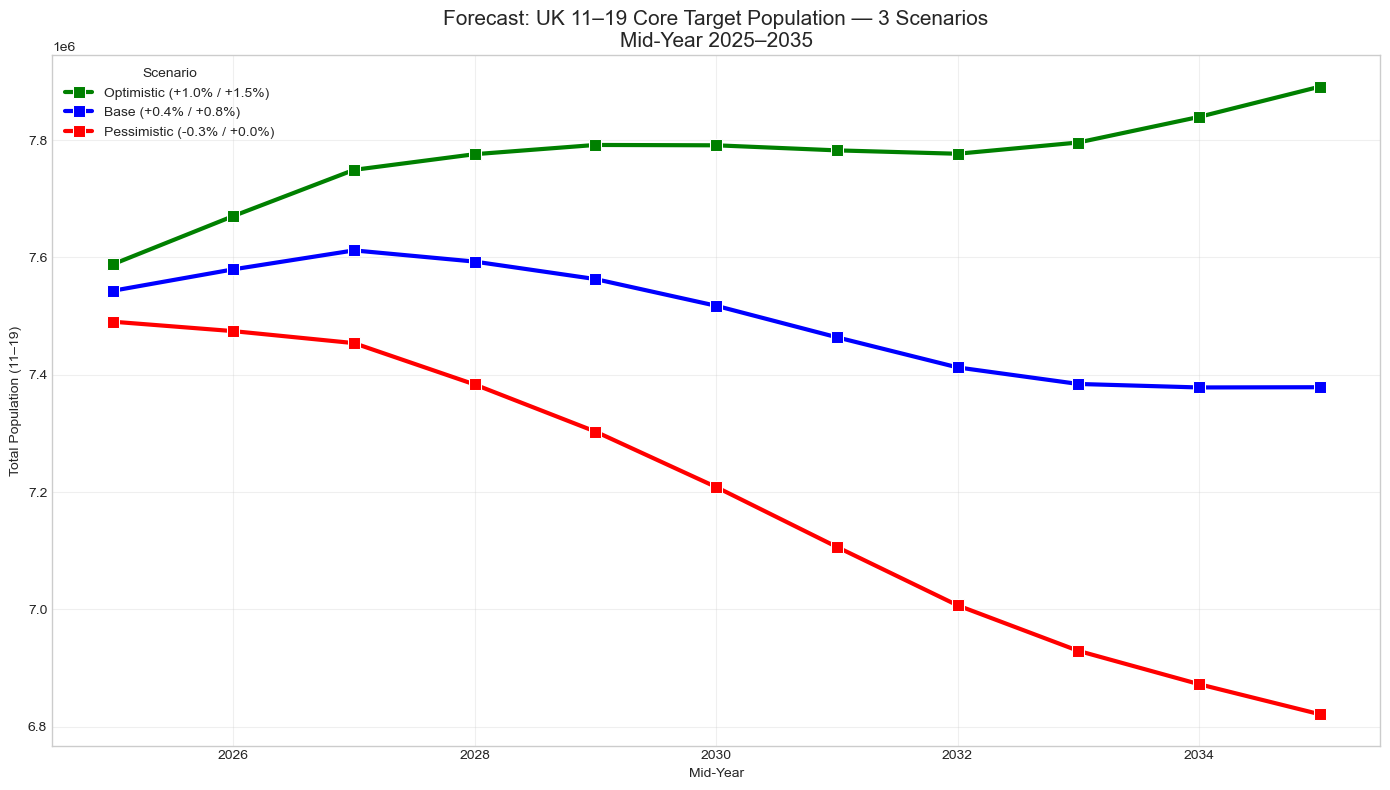

In [6]:
scenarios_cfg = {
    'Optimistic (+1.0% / +1.5%)':  {'survival_rate': 1.010, 'incoming_growth': 1.015},
    'Base (+0.4% / +0.8%)':        {'survival_rate': 1.004, 'incoming_growth': 1.008},
    'Pessimistic (-0.3% / +0.0%)': {'survival_rate': 0.997, 'incoming_growth': 1.000},
}

all_scenarios = []
for name, rates in scenarios_cfg.items():
    f = make_forecast(**rates)
    f['Scenario'] = name
    all_scenarios.append(f)

scenarios_df = pd.concat(all_scenarios)

# Store individual scenarios for pipeline chart
opt = make_forecast(survival_rate=1.010, incoming_growth=1.015)
pes = make_forecast(survival_rate=0.997, incoming_growth=1.000)

# Plot: 3-scenario 11–19 core target
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=scenarios_df, x='mid_year', y='Total_11_19',
    hue='Scenario', palette=['green', 'blue', 'red'],
    linewidth=3, marker='s', markersize=8
)

plt.title('Forecast: UK 11–19 Core Target Population — 3 Scenarios\n'
          'Mid-Year 2025–2035', fontsize=15)
plt.xlabel('Mid-Year')
plt.ylabel('Total Population (11–19)')
plt.legend(title='Scenario', loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart Commentary — Cohort-Component Forecast

**How it works:** The model rolls forward real historical cohorts (actual 2024 populations by age from ONS data) year-by-year to 2035. Each age group ages up one year, a survival/growth factor accounts for net migration, and new 5-year-olds enter at a growth rate reflecting recent migration-driven trends.

**Three scenarios:**
- **Optimistic** (+1.0% survival / +1.5% incoming): 11–19 climbs toward ~7.9M+ by 2035. Assumes sustained higher migration.
- **Base** (+0.4% / +0.8%): 11–19 stable at ~7.4–7.6M early, gentle softening to ~7.38M by 2035.
- **Pessimistic** (-0.3% / +0.0%): 11–19 declines to ~6.8M — still no collapse.

Even the pessimistic case keeps the 11–19 population above 6.8 million. This is not a shrinking market — it is a stable market with reliable replenishment from younger cohorts.

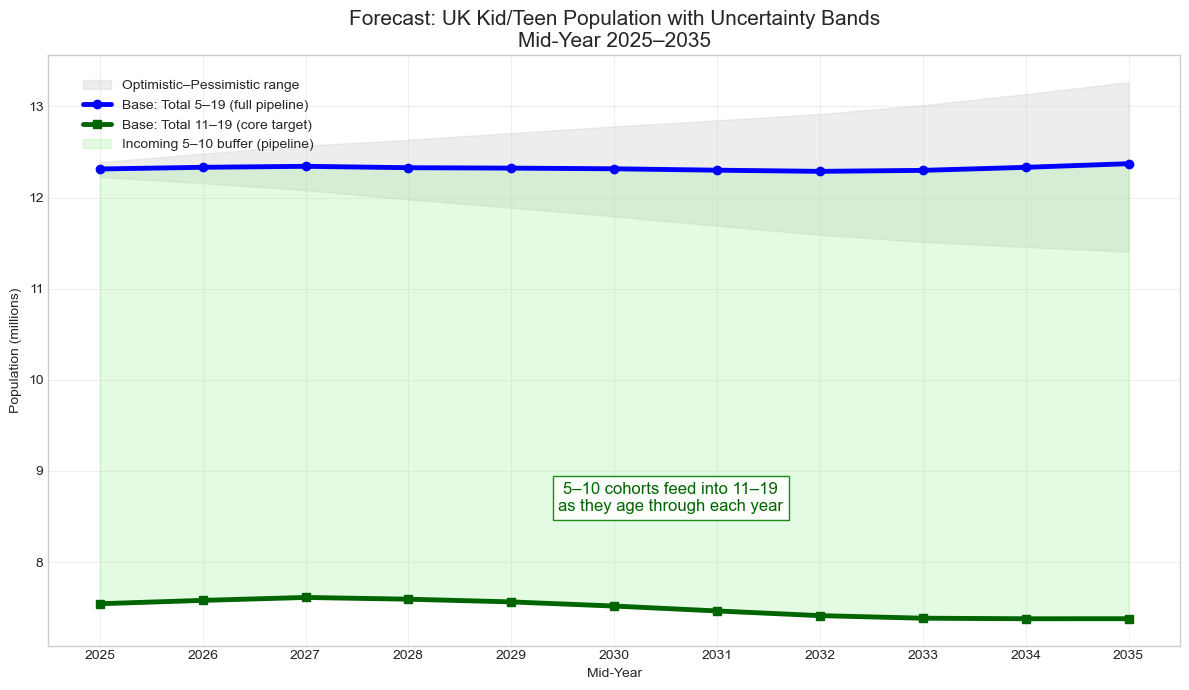

In [7]:
forecast_m = forecast.copy()
forecast_m['Total_5_19'] = forecast_m['Total_5_19'] / 1_000_000
forecast_m['Total_11_19'] = forecast_m['Total_11_19'] / 1_000_000

opt_m = opt.copy()
opt_m['Total_5_19'] = opt_m['Total_5_19'] / 1_000_000
if 'Total_11_19' in opt_m.columns:
    opt_m['Total_11_19'] = opt_m['Total_11_19'] / 1_000_000

pes_m = pes.copy()
pes_m['Total_5_19'] = pes_m['Total_5_19'] / 1_000_000
if 'Total_11_19' in pes_m.columns:
    pes_m['Total_11_19'] = pes_m['Total_11_19'] / 1_000_000

forecast_m = forecast_m.sort_values('mid_year')
opt_m = opt_m.sort_values('mid_year')
pes_m = pes_m.sort_values('mid_year')

plt.figure(figsize=(12, 7))

plt.fill_between(forecast_m['mid_year'],
                 pes_m['Total_5_19'], opt_m['Total_5_19'],
                 color='lightgray', alpha=0.4,
                 label='Optimistic–Pessimistic range')

plt.plot(forecast_m['mid_year'], forecast_m['Total_5_19'],
         label='Base: Total 5–19 (full pipeline)', color='blue', linewidth=3.5, marker='o')
plt.plot(forecast_m['mid_year'], forecast_m['Total_11_19'],
         label='Base: Total 11–19 (core target)', color='darkgreen', linewidth=3.5, marker='s')

plt.fill_between(forecast_m['mid_year'],
                 forecast_m['Total_11_19'], forecast_m['Total_5_19'],
                 color='lightgreen', alpha=0.25, label='Incoming 5–10 buffer (pipeline)')

plt.title('Forecast: UK Kid/Teen Population with Uncertainty Bands\n'
          'Mid-Year 2025–2035', fontsize=15)
plt.xlabel('Mid-Year')
plt.ylabel('Population (millions)')
plt.xticks(forecast_m['mid_year'], rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))
plt.grid(True, alpha=0.3)

plt.text(0.55, 0.25,
         '5–10 cohorts feed into 11–19\nas they age through each year',
         fontsize=12, color='darkgreen', ha='center', va='center',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='green'))

plt.tight_layout()
plt.show()

### Chart Commentary — Pipeline vs Core Target

The blue line (total 5–19) represents the full pipeline — all children who will eventually age into the core target. The green line (11–19) is the addressable demographic today. The light green shaded area shows the incoming buffer: younger children (5–10) who will move into the 11–19 range over the forecast period.

The core 11–19 population remains largely stable — neither collapsing nor exploding. A steady stream of younger children continues to replenish the market each year. For a new brand, this means predictable demand volume and the opportunity to build loyalty as cohorts age through the range.

---
## Section 5: Gap Sizing — Addressable Market Estimate

Using the demographic base from the forecast model to estimate the serviceable addressable market.

In [8]:
# From base forecast: Total 11–19 in 2025
uk_total_11_19_2025 = int(forecast[forecast['mid_year'] == 2025]['Total_11_19'].values[0])
uk_girls_11_19 = int(uk_total_11_19_2025 * 0.495)  # ~49.5% female

# AOV derivation:
# Mass-market ceiling: ~£33 (Next max from notebook 01)
# Nearest above-mass-market kids entry: £44–45 (Pink Chicken kids, D&D kids)
# £40 sits in the gap between these two reference points.
avg_order_value = 40

# SAM assumptions — range of penetration rates
# What % of girls aged 11–19 buy one sleepwear item per year at this price point?
for label, pen in [('Conservative (1%)', 0.01), ('Moderate (3%)', 0.03), ('Optimistic (5%)', 0.05)]:
    sam = uk_girls_11_19 * pen * avg_order_value
    print(f'{label}: {uk_girls_11_19 * pen:,.0f} customers × £{avg_order_value} = £{sam/1e6:.1f}M')

print(f'\nDemographic base: {uk_total_11_19_2025:,} total 11–19 | {uk_girls_11_19:,} girls (~49.5%)')
print(f'AOV of £{avg_order_value} derived from gap between mass-market ceiling (~£33) and nearest kids entry (~£44)')
print(f'\nNotes:')
print(f'  - Full TAM larger if including boys, repeat purchases, or multi-item orders')
print(f'  - Christmas gifting (~5x seasonal uplift per notebook 02) would concentrate demand in Q4')

Conservative (1%): 37,339 customers × £40 = £1.5M
Moderate (3%): 112,016 customers × £40 = £4.5M
Optimistic (5%): 186,693 customers × £40 = £7.5M

Demographic base: 7,543,139 total 11–19 | 3,733,853 girls (~49.5%)
AOV of £40 derived from gap between mass-market ceiling (~£33) and nearest kids entry (~£44)

Notes:
  - Full TAM larger if including boys, repeat purchases, or multi-item orders
  - Christmas gifting (~5x seasonal uplift per notebook 02) would concentrate demand in Q4


### Commentary — Gap Sizing

These are rough estimates intended to frame the order of magnitude, not predict revenue. The conservative scenario (1% penetration, £40 AOV) suggests a ~£1.5M addressable market for girls' teen sleepwear in the UK, rising to ~£4.5M at 3% penetration.

The AOV of £40 is derived from the pricing data: it sits in the gap between the mass-market ceiling (~£33, Next) and the nearest above-mass-market kids sleepwear entry (~£44, Pink Chicken kids / D&D kids). This is not a target price recommendation — it is a reference point for sizing the opportunity.

The estimates are deliberately conservative: they exclude boys entirely, assume single-item annual purchase, and use a mid-range AOV. Repeat purchasing, multi-item orders, and eventual boys/unisex expansion would increase the addressable market.

**Sensitivity note:** The penetration rate is the most sensitive assumption in this model — changing it from 1% to 5% quintuples the market size estimate. Without actual sales data from comparable UK launches, any specific penetration rate is speculative. For context, even established mass-market brands with national store networks and significant marketing spend would not typically achieve 20%+ penetration in a specific clothing subcategory. A bootstrapped DTC brand with no physical retail presence is operating at a fundamentally smaller scale. The scenarios above are presented to illustrate the range of possible outcomes rather than predict a specific market size.

---
## Section 6: Risks, Barriers & Open Questions

### Potential Moats
- TikTok/IG-native virality + founder authenticity (PPP model demonstrates this works)
- Quality materials and ethical sourcing — harder for fast fashion to replicate credibly
- Teen-specific sizing, aesthetics, and community — not easily backward-extended from adult brands
- Loyalty compounding: teens who connect with a brand at 12–13 can stay through to 18–19

### Key Risks & Barriers
- **Fast-fashion fast-follow:** Primark or H&M could launch a teen-aesthetic PJ line within one season at a fraction of the price. The defence is brand identity and community — PPP has survived SHEIN copying its prints because the brand itself is the product, not the garment.
- **Teen trend volatility:** What's cool at 13 changes fast. A brand built on a single aesthetic risks irrelevance within 2–3 years if it can't evolve.
- **Scaling founder-led authenticity:** The PPP model works because the founder IS the brand. Replicating this without a genuine founder-influencer is much harder.
- **Social algorithm dependency:** TikTok's algorithm can giveth and taketh away. A brand wholly dependent on one platform is fragile.
- **Supply chain costs:** Quality fabrics + small batch sizes = tight margins at launch.

### Open Questions — Honest Unknowns

**Will teens/parents pay above mass-market prices specifically for sleepwear?**
This is the central untested hypothesis. The data shows:
- Parents pay £44–57 for kids sleepwear from quality brands (D&D kids, Roller Rabbit kids, Eberjey kids, Pink Chicken)
- Teens/parents pay £54–75 for teen apparel with strong identity (Katie J NYC, PPP)
- The Christmas gifting moment supports higher price points than everyday self-purchase
- The `matching family PJs` search trend (notebook 02) shows sleepwear-specific demand exists at above-mass-market prices

But PPP and Katie J NYC are not sleepwear-only brands — their sleepwear is secondary to hoodies and apparel respectively. Whether a standalone teen sleepwear brand can command above-mass-market pricing is unproven by this dataset. D&D validates quality sleepwear as a category; the open question is whether the teen demographic specifically supports it.

**Is the product sleepwear or loungewear?**
The identity value of sleepwear (worn at home, not seen) is inherently lower than outerwear (worn publicly, status signal). The strongest commercial angle may be the overlap — products that function as comfortable at-home wear that teens are happy to be seen in (on video calls, in content, when friends visit) while also being sleepwear. This is a product design question, not a market analysis question, but it materially affects pricing power.

**Is the 11–19 range too broad?**
An 11-year-old and a 19-year-old are different consumers. The brand may need to target a narrower band (e.g., 11–15 parent-purchased gifting, or 15–19 self-purchased identity wear) rather than the full range.

---
## Section 7: Key Findings

### Summary

1. **Stable demographic base.** The UK 11–19 population is ~7.5M (mid-2025 estimate) and remains stable across all forecast scenarios through 2035. Even the pessimistic case holds above 6.8M. The market is not shrinking.

2. **Reliable pipeline replenishment.** The 5–10 age group continuously feeds into the 11–19 target range. A brand that builds awareness early can capture customers as they age into the core demographic.

3. **Addressable market is small but viable.** At 1% penetration and £40 AOV (derived from the gap between mass-market ceiling and nearest above-mass-market entry), the girls-only addressable market is ~£1.5M, rising to ~£4.5M at 3%. This is appropriate for a bootstrapped DTC brand. Christmas gifting concentration provides a natural revenue peak.

4. **The positioning gap is confirmed but the demand hypothesis is untested.** Multiple US brands validate above-mass-market pricing for kids apparel and kids sleepwear separately. No brand has proven that teen-specific sleepwear is a standalone category at this price point. Supporting signals exist (gifting behaviour, matching PJ trends, PPP's expansion into pyjamas) but the hypothesis requires market testing.

5. **Risk is manageable with the right model.** Fast-fashion fast-follow, trend volatility, and algorithm dependency are real risks. The PPP case study suggests that strong brand identity and community are the primary defences — not product design or price point.

---

*Next: Notebook 06 — Financial Modelling (revenue scenarios, unit economics, break-even analysis) — coming soon*